## TP1 - Estimation de $\lambda$ et $\mu$ sur des architectures

**Travail pratique de modélisation des files d'attente**

## Objectifs pédagogiques
- Identifier ce qu'est un « client » et un « serveur » dans une architecture informatique réelle (web, mobile).
- Estimer le taux d'arrivée $\lambda$ et le taux de service $\mu$ par les méthodes du moment et du maximum de vraisemblance.

## Pré-requis
- Connaissance des modèles M/M/1 et M/M/c, de la notation de Kendall et de la loi de Little.
- Maîtrise élémentaire de Python et de Pandas (lecture CSV, agrégation, tracé).
- Notions de statistique descriptive (moyenne, variance, histogramme).

## Livrables
- Un notebook Jupyter ou un script Python complet et commenté.*italicized text*

## Partie 0 — Mise en place et rappels

### 0.1 Le triplet client - serveur - discipline dans une architecture
Avant tout calcul, il faut identifier dans chaque système ce qui constitue un client, ce qui constitue un serveur, et ce qui se trouve dans la file d'attente.

| Architecture | Client | Serveur(s) | File d'attente |
| :--- | :--- | :--- | :--- |
| Serveur web | Requête HTTP | Worker / process / thread | Backlog TCP, queue applicative |
| API mobile | Appel REST | Pool de threads servlet | Queue du pool de threads
### 0.2 Ce que mesure un log
Les serveurs produisent presque tous des logs au format CSV ou texte structuré.
Pour estimer $\lambda$ et $\mu$ il vous faut deux colonnes au minimum :
- **Timestamp d'arrivée** : l'instant où la requête a touché le système.
- **Durée de traitement** : le temps total entre l'entrée et la sortie de la requête.

### 0.3 Méthode d'estimation
Pour un échantillon de $n$ inter-arrivées supposées indépendantes et exponentielles de paramètre $\lambda$, l'estimateur du maximum de vraisemblance est :
$$\hat{\lambda} = \frac{1}{\bar{T}} \quad \text{où} \quad \bar{T} = \frac{1}{n} \sum T_i$$

Et de même pour les durées de service $S_i$ supposées exponentielles de paramètre $\mu$ :
$$\hat{\mu} = \frac{1}{\bar{S}}$$
Soit un échantillon de variables aléatoires :
$T_1, T_2, \dots, T_n$
 **indépendantes et identiquement distribuées** suivant une loi exponentielle de paramètre $ \lambda > 0 $ (voir cours) :

$$
T_i \sim \text{Exp}(\lambda)
$$

La densité de probabilité est :
$$
f(t; \lambda) = \lambda e^{-\lambda t}, \quad t \ge 0
$$

---
La fonction de vraisemblance est donnée par :
$$ \mathcal{L}(\lambda) = \prod_{i=1}^{n} f(T_i; \lambda) $$

Donc :
$$
\mathcal{L}(\lambda) = \prod_{i=1}^{n} \lambda e^{-\lambda T_i}
= \lambda^n \exp\left(-\lambda \sum_{i=1}^{n} T_i \right)
$$

---

Avec la log-vraisemblance :

$$
\ell(\lambda) = \log \mathcal{L}(\lambda)
$$

$$
\ell(\lambda) = n \log \lambda - \lambda \sum_{i=1}^{n} T_i
$$

---

On dérive par rapport à \(\lambda\) :

$$
\frac{d\ell}{d\lambda} = \frac{n}{\lambda} - \sum_{i=1}^{n} T_i
$$

On cherche le point critique :

$$
\frac{n}{\lambda} - \sum T_i = 0
$$

---
On résout :

$$
\frac{n}{\lambda} = \sum_{i=1}^{n} T_i
$$

$$
\hat{\lambda} = \frac{n}{\sum_{i=1}^{n} T_i}
$$

En introduisant la moyenne empirique :

$$
\bar{T} = \frac{1}{n} \sum_{i=1}^{n} T_i
$$

on obtient :

$$
\hat{\lambda} = \frac{1}{\bar{T}}
$$

Si
$
S_1, \dots, S_n \sim \text{Exp}(\mu)
$

Alors, de manière identique :

$$
\hat{\mu} = \frac{1}{\bar{S}}
$$

avec :
$$
\bar{S} = \frac{1}{n} \sum_{i=1}^{n} S_i
$$

---

## Interprétation

- $ \lambda $ : taux d'arrivée (nombre moyen d'événements par unité de temps)
- $ \mu $ : taux de service

Ainsi :
$$
\lambda = \frac{1}{\mathbb{E}[T]}, \quad \mu = \frac{1}{\mathbb{E}[S]}
$$

Les estimateurs remplacent simplement l'espérance par la moyenne empirique.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Partie 1 — Serveur web (Nginx)

### 1.1 Contexte
Vous administrez le serveur Nginx d'une application. Vous voulez savoir si le serveur actuel est correctement dimensionné.
Vous disposez d'un extrait du fichier `access.log` enrichi avec `request_time`.

### 1. Questions

#### Question 1.1 — Lecture et exploration
Charger le fichier `nginx_access.csv`. Convertir la colonne timestamp en datetime.
Afficher le nombre total de requêtes, la plage horaire couverte et la statistique descriptive de `request_time`.

In [2]:
df_nginx = pd.read_csv("nginx_access.csv")
df_nginx["timestamp"] = pd.to_datetime(df_nginx["timestamp"])
df_nginx = df_nginx.sort_values("timestamp").reset_index(drop=True)

print("Nombre total de requêtes :", len(df_nginx))
print("Plage horaire :", df_nginx["timestamp"].min(), "→", df_nginx["timestamp"].max())
print("Durée totale  :", df_nginx["timestamp"].max() - df_nginx["timestamp"].min())
print()
print("Statistiques de request_time (s) :")
print(df_nginx["request_time"].describe())


Nombre total de requêtes : 10605
Plage horaire : 2026-05-04 09:00:00.049606 → 2026-05-04 09:59:59.976449
Durée totale  : 0 days 00:59:59.926843

Statistiques de request_time (s) :
count    10605.000000
mean         0.197128
std          0.199677
min          0.000012
25%          0.057595
50%          0.136285
75%          0.271658
max          2.432702
Name: request_time, dtype: float64


#### Question 1.2 — Estimation de $\lambda$
Calculer la suite des inter-arrivées (différences entre timestamps successifs). En déduire l'estimateur $\hat{\lambda}$ par la moyenne empirique.
Donner la valeur en req/s et req/min.

In [3]:
# Inter-arrivées : différences entre timestamps successifs
inter_arr = df_nginx["timestamp"].diff().dt.total_seconds().dropna()

T_bar = inter_arr.mean()
lambda_hat = 1 / T_bar

print(f"Inter-arrivée moyenne T̄ = {T_bar:.4f} s")
print(f"λ̂ = 1/T̄ = {lambda_hat:.4f} req/s")
print(f"λ̂ = {lambda_hat*60:.2f} req/min")


Inter-arrivée moyenne T̄ = 0.3395 s
λ̂ = 1/T̄ = 2.9456 req/s
λ̂ = 176.74 req/min


#### Question 1.3 — Estimation de $\mu$
À partir de la colonne `request_time`, calculer l'estimateur $\hat{\mu}$. Comparer la moyenne et l'écart-type pour discuter de l'hypothèse exponentielle.

In [4]:
S = df_nginx["request_time"]
S_bar = S.mean()
S_std = S.std()
mu_hat = 1 / S_bar
cv_S = S_std / S_bar

print(f"Durée de service moyenne S̄ = {S_bar:.4f} s")
print(f"Écart-type des durées de service = {S_std:.4f} s")
print(f"μ̂ = 1/S̄ = {mu_hat:.4f} req/s")
print(f"Coefficient de variation CV = σ/μ = {cv_S:.3f}")
print()
print("Pour une loi exponentielle on attend moyenne ≈ écart-type, donc CV ≈ 1.")


Durée de service moyenne S̄ = 0.1971 s
Écart-type des durées de service = 0.1997 s
μ̂ = 1/S̄ = 5.0729 req/s
Coefficient de variation CV = σ/μ = 1.013

Pour une loi exponentielle on attend moyenne ≈ écart-type, donc CV ≈ 1.


#### Question 1.4 — Vérification graphique des hypothèses
Tracer l'histogramme des inter-arrivées et superposer la densité exponentielle ajustée. Faire de même pour les durées de service.

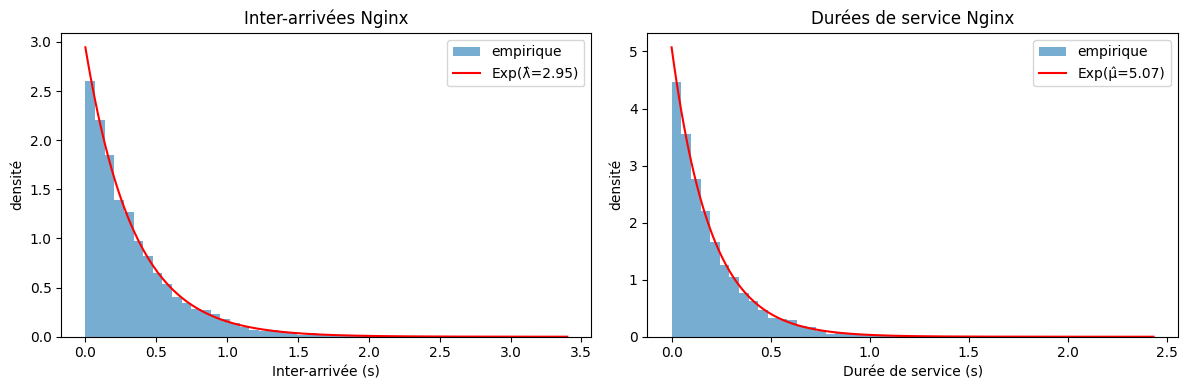

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Inter-arrivées
ax = axes[0]
ax.hist(inter_arr, bins=50, density=True, alpha=0.6, label="empirique")
t = np.linspace(0, inter_arr.max(), 200)
ax.plot(t, lambda_hat * np.exp(-lambda_hat * t), "r-", label=f"Exp(λ̂={lambda_hat:.2f})")
ax.set_xlabel("Inter-arrivée (s)")
ax.set_ylabel("densité")
ax.set_title("Inter-arrivées Nginx")
ax.legend()

# Durées de service
ax = axes[1]
ax.hist(S, bins=50, density=True, alpha=0.6, label="empirique")
s = np.linspace(0, S.max(), 200)
ax.plot(s, mu_hat * np.exp(-mu_hat * s), "r-", label=f"Exp(μ̂={mu_hat:.2f})")
ax.set_xlabel("Durée de service (s)")
ax.set_ylabel("densité")
ax.set_title("Durées de service Nginx")
ax.legend()

plt.tight_layout()
plt.show()


## Partie 2 — API mobile (M/M/c)

### 2.1 Contexte
L'application mobile consomme une API REST hébergée sur un serveur Spring Boot
avec un pool de threads servlet. Le fichier `api_mobile.csv` contient les colonnes
`arrival`, `service`, `start`, `departure`. La taille du pool **n'est pas
documentée** : il faut la retrouver à partir des données.

### 2.2 — Estimation de λ et μ
Charger `api_mobile.csv`. Calculer les inter-arrivées et estimer
$\hat{\lambda} = 1/\bar{T}$, puis estimer $\hat{\mu} = 1/\bar{S}$ à partir de la
colonne `service`. Reporter les coefficients de variation des inter-arrivées
et des durées de service ; conclure sur la plausibilité des hypothèses
markoviennes.

### 2.3 — Estimation empirique du nombre de serveurs c

Le fichier contient une colonne `thread` indiquant l'identifiant du thread ayant traité chaque requête.

**Principe.** À tout instant t, le nombre de requêtes en cours de service est :
$$N_s(t) = \#\{ i \;:\; \texttt{start}_i \le t < \texttt{departure}_i \}$$
La capacité c du pool est, par définition, le **maximum** que cette quantité peut
atteindre. Si le système est suffisamment chargé pendant la période d'observation,
on aura presque sûrement $\max_t N_s(t) = c$.

**Question 2.3.a.** Implémenter la fonction `serveurs_occupes(log, t)` qui renvoie
$N_s(t)$. L'évaluer sur une grille fine d'instants couvrant la durée de simulation
et tracer $N_s(t)$ en fonction du temps.

**Question 2.3.b.** En déduire l'estimateur :
$$\hat{c} = \max_t N_s(t)$$
Donner sa valeur. Tracer une ligne horizontale rouge à $\hat{c}$ sur le graphique
précédent.

**Question 2.3.c.** Calculer la **fraction du temps** où le pool est saturé,
c'est-à-dire la proportion d'instants où $N_s(t) = \hat{c}$. Interpréter : un
système souvent saturé est sous-dimensionné.
**Question 2.3.c.** Calculer le taux d'utilisation global du système $$ \rho $$  à l'aide de la formule :

$$\rho = \frac{\lambda}{c\mu}$$

Interpréter la valeur obtenue afin d’évaluer la stabilité du modèle avant de procéder à l’analyse empirique.

In [6]:
# Partie 2 — API mobile
df_api = pd.read_csv("api_mobile.csv").sort_values("arrival").reset_index(drop=True)
print(df_api.head())
print(f"\nNombre de requêtes : {len(df_api)}")

# Inter-arrivées
inter_arr_api = df_api["arrival"].diff().dropna()
T_bar = inter_arr_api.mean()
lambda_api = 1 / T_bar

# Durées de service
S_api = df_api["service"]
S_bar = S_api.mean()
mu_api = 1 / S_bar

cv_T = inter_arr_api.std() / T_bar
cv_S = S_api.std() / S_bar

print(f"\nλ̂ = {lambda_api:.4f} req/s")
print(f"μ̂ = {mu_api:.4f} req/s")
print(f"CV inter-arrivées = {cv_T:.3f}")
print(f"CV durées de service = {cv_S:.3f}")
print("\nLes hypothèses markoviennes (M/M/c) sont plausibles si les CV sont proches de 1.")


    arrival   service     start  departure  thread
0  0.001282  0.303509  0.001282   0.304791       0
1  0.124299  0.168560  0.124299   0.292859       1
2  0.152384  0.028271  0.152384   0.180655       2
3  0.218618  0.037466  0.218618   0.256084       3
4  0.342735  0.013047  0.342735   0.355783       2

Nombre de requêtes : 21547

λ̂ = 11.9705 req/s
μ̂ = 3.9996 req/s
CV inter-arrivées = 0.999
CV durées de service = 1.005

Les hypothèses markoviennes (M/M/c) sont plausibles si les CV sont proches de 1.


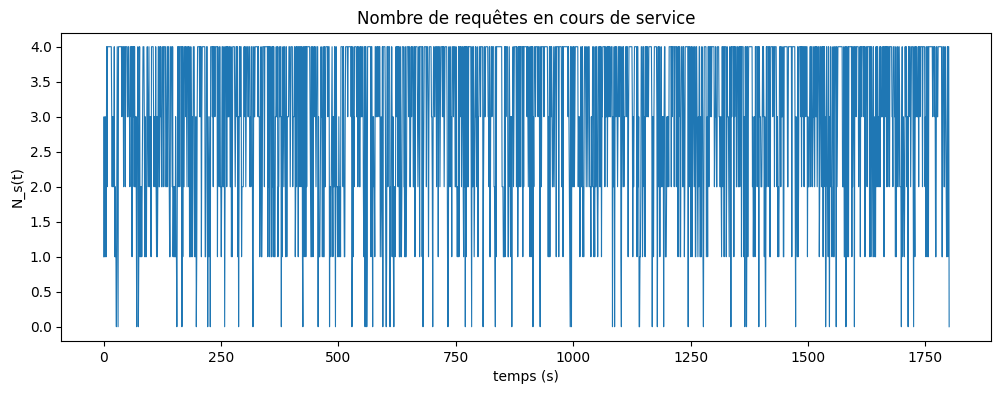

In [7]:
# Question 2.3.a — Ns(t) : nombre de requêtes en cours de service à l'instant t
def serveurs_occupes(log, t):
    return int(((log["start"] <= t) & (log["departure"] > t)).sum())

t_min = df_api["start"].min()
t_max = df_api["departure"].max()
grid = np.linspace(t_min, t_max, 2000)
Ns = np.array([serveurs_occupes(df_api, t) for t in grid])

plt.figure(figsize=(12, 4))
plt.plot(grid, Ns, lw=0.8)
plt.xlabel("temps (s)")
plt.ylabel("N_s(t)")
plt.title("Nombre de requêtes en cours de service")
plt.show()


ĉ = max_t N_s(t) = 4
Nombre distinct de threads observés dans les logs = 4


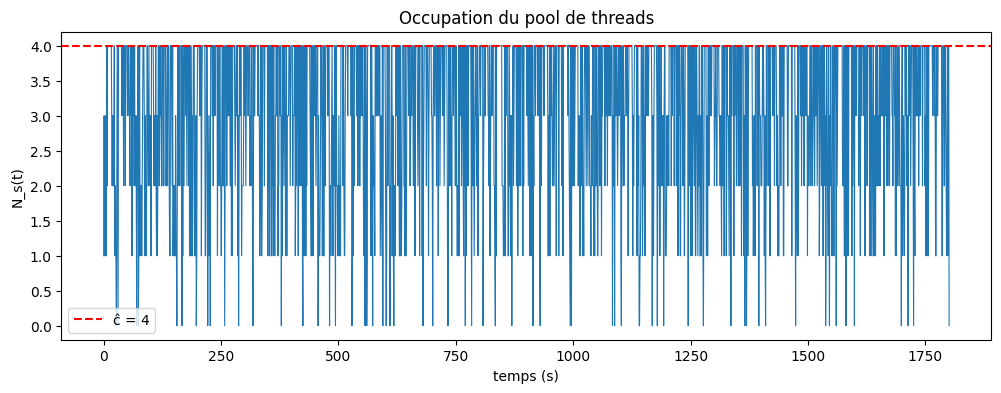

In [8]:
# Question 2.3.b — ĉ = max N_s(t)
c_hat = int(Ns.max())
print(f"ĉ = max_t N_s(t) = {c_hat}")
print(f"Nombre distinct de threads observés dans les logs = {df_api['thread'].nunique()}")

plt.figure(figsize=(12, 4))
plt.plot(grid, Ns, lw=0.8)
plt.axhline(c_hat, color="red", linestyle="--", label=f"ĉ = {c_hat}")
plt.xlabel("temps (s)")
plt.ylabel("N_s(t)")
plt.title("Occupation du pool de threads")
plt.legend()
plt.show()


In [9]:
# Question 2.3.c — fraction de temps saturé + taux d'utilisation ρ
frac_sat = float((Ns == c_hat).mean())
rho = lambda_api / (c_hat * mu_api)

print(f"Fraction du temps où N_s(t) = ĉ : {frac_sat:.3%}")
print(f"ρ = λ / (c μ) = {lambda_api:.4f} / ({c_hat} × {mu_api:.4f}) = {rho:.3f}")
print()
if rho < 1:
    print("ρ < 1 → le système est stable (file bornée en régime stationnaire).")
else:
    print("ρ ≥ 1 → le système est instable, la file diverge : pool sous-dimensionné.")

if frac_sat > 0.5:
    print("Le pool est saturé plus de la moitié du temps : système clairement sous-dimensionné.")
elif frac_sat > 0.1:
    print("Saturation non négligeable : marge faible.")
else:
    print("Saturation rare : dimensionnement confortable.")


Fraction du temps où N_s(t) = ĉ : 51.000%
ρ = λ / (c μ) = 11.9705 / (4 × 3.9996) = 0.748

ρ < 1 → le système est stable (file bornée en régime stationnaire).
Le pool est saturé plus de la moitié du temps : système clairement sous-dimensionné.
